In [2]:
import os
import re
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tbparse import SummaryReader
from tueplots import bundles

# Keep plotting style consistent with existing slides
plt.rcParams.update(bundles.beamer_moml())
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'figure.dpi': 200})

# change directory to project root
os.chdir(os.path.expanduser("~/Desktop/pomdp_coder"))
print(os.getcwd())
base_dir = os.path.join("outputs")

C:\Users\Frederik\Desktop\pomdp_coder


In [48]:
def load_avg_reward_df(path: str):
    """Return the Average Episode Reward scalars for a given experiment directory."""
    reader = SummaryReader(path, extra_columns={'dir_name'})
    df = reader.scalars
    return df[df['tag'] == "Episode Reward"].reset_index(drop=True)
    # return df[df['tag'] == "Average Episode Reward"].reset_index(drop=True)

def get_clean_df_exp1(path: str):
    """Return a cleaned DataFrame with only relevant columns."""
    df = load_avg_reward_df(path)
    df['attempts'] = df['dir_name'].apply(lambda x: re.search(r"_attempts(\d+)", x).group(1))
    df['seed'] = df['dir_name'].apply(lambda x: re.search(r"_seed(\d+)", x).group(1))
    df['episode'] = df['step'] 
    df = df.drop(columns=['tag', 'step', 'dir_name'])
    df = df[['attempts', 'seed', 'episode', 'value']]
    return df

In [49]:
path = os.path.join(base_dir, "rocksample", "ours", "2025-12-03")
df = get_clean_df_exp1(path)
df.head()

,attempts,seed,episode,value
0,10,1,0,12.208961
1,10,1,1,3.821338
2,10,1,2,10.000000
3,10,1,3,11.604774
4,10,1,4,21.570034


In [50]:
df_5 = pd.read_csv(os.path.join(base_dir, "process_outputs", "baseline_results.csv"))
df_5 = df_5[(df_5['approach'] == "ours") & (df_5['environment'] == "rocksample")]
df_5 = df_5.drop(columns=['environment', 'approach'])
df_5["attempts"] = "5"
df_5 = df_5[['attempts', 'seed', 'episode', 'value']]
df_5.head()

,attempts,seed,episode,value
500,5,0,0,7.936056
501,5,0,1,4.348660
502,5,0,2,-8.017041
503,5,0,3,-10.266643
504,5,0,4,-5.024959


In [ ]:
df = pd.concat([df_5, df], ignore_index=True)

In [63]:
df_avg = df.groupby('attempts')['value'].agg(['mean', 'sem']).reset_index()
df_avg['attempts'] = pd.to_numeric(df_avg['attempts'])
df_avg = df_avg.sort_values('attempts')
df_avg

,attempts,mean,sem
4,5,2.699009,0.867762
0,10,2.541401,0.874410
1,15,4.748024,0.881951
2,20,1.316659,1.595236
3,25,-2.176993,1.756716


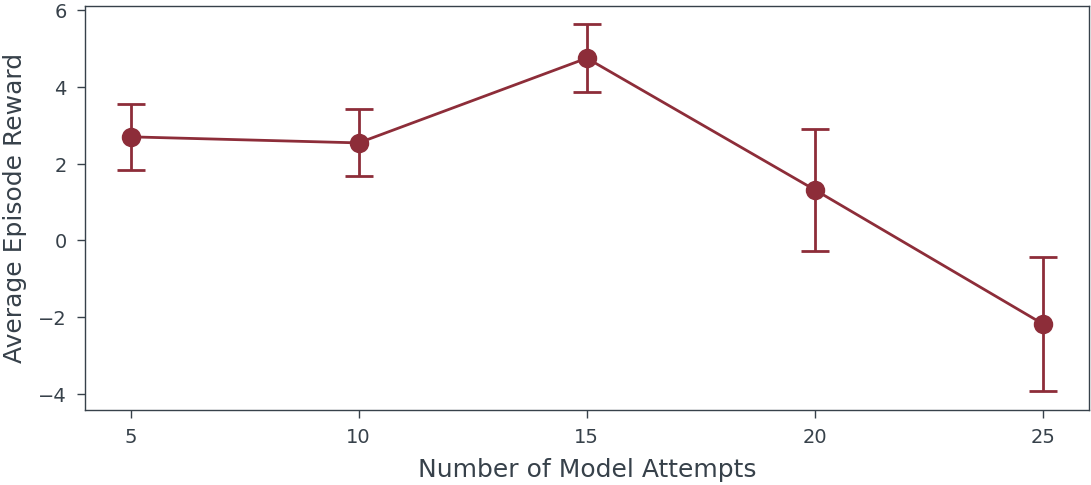

In [66]:
fig, ax = plt.subplots()
ax.errorbar(df_avg["attempts"], df_avg['mean'], yerr=df_avg['sem'], 
            marker='o', capsize=5, label='Average Reward')
ax.set_xlabel('Number of Model Attempts')
ax.set_xticks(df_avg["attempts"]) 
ax.set_ylabel('Average Episode Reward')
plt.show()